# Análisis de textos

---

El *Procesamiento de Lenguaje Natural (NLP)* es una rama de la inteligencia artificial que permite a las computadoras entender, interpretar y generar lenguaje humano. Su objetivo es transformar textos o discursos en datos que una máquina pueda analizar, facilitando tareas como traducción automática, chatbots, análisis de sentimientos o motores de búsqueda. 📖🤖


##  Vectorización de textos

---

La *vectorización de textos* es el proceso de transformar palabras o frases en representaciones numéricas que las computadoras puedan procesar. 📊 En lugar de trabajar con texto plano, lo convertimos en vectores que permiten a los algoritmos de machine learning analizar, comparar y encontrar patrones en el lenguaje. ✨


In [1]:
#!pip install wordcloud spacy

In [22]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import spacy


In [3]:
#spacy.cli.download("es_core_news_sm")
nlp = spacy.load("es_core_news_sm")

In [4]:
sns.set_style('whitegrid')
sns.set_palette('viridis')

<center>
  <img src="https://i5.walmartimages.com.mx/gr/images/product-images/img_large/00360054263068L.jpg" alt="Regresion Descenso de Gradiente" style="max-width:50%; height:auto;"  width="30%">
</center>

In [5]:
opiniones=pd.read_csv("https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/16-ds-analisis-textos/opiniones_garnier.csv")
opiniones

,Comentario,Label
0,"Me encantó, dejó mi piel muy suave y luminosa",positiva
1,"Excelente aroma cítrico, refresca cada mañana",positiva
2,Mi piel se ve más uniforme después de usarlo,positiva
3,Textura ligera y se enjuaga fácilmente,positiva
4,Noté menos manchas en pocas semanas,positiva
5,La vitamina C me deja sensación de frescura,positiva
6,Muy buena relación calidad precio,positiva
7,Funciona bien para limpiar sin resecar,positiva
8,La piel queda brillante y nutrida,positiva
9,Me gusta que no contiene sulfatos,positiva


In [6]:
opiniones.shape, opiniones.Label.value_counts()

((30, 2),
 Label
 positiva    12
 negativa    10
 neutra       8
 Name: count, dtype: int64)

In [7]:
# Longitud de comentarios y distribución
opiniones["len"] = opiniones["Comentario"].str.len()
opiniones["n_words"] = opiniones["Comentario"].apply(lambda x: len(x.split()))
opiniones.groupby("Label")["len"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
negativa,10.0,31.90,5.526703,22.0,29.5,33.0,35.75,39.0
neutra,8.0,31.75,4.166190,24.0,31.0,32.5,33.25,38.0
positiva,12.0,39.00,4.709758,33.0,34.5,39.0,43.25,45.0


In [8]:
#Cantidad de palabras
opiniones.groupby("Label")["n_words"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
negativa,10.0,5.800,1.135292,4.0,5.0,6.0,6.0,8.0
neutra,8.0,5.625,1.060660,4.0,5.5,6.0,6.0,7.0
positiva,12.0,6.500,1.381699,5.0,6.0,6.0,6.5,9.0


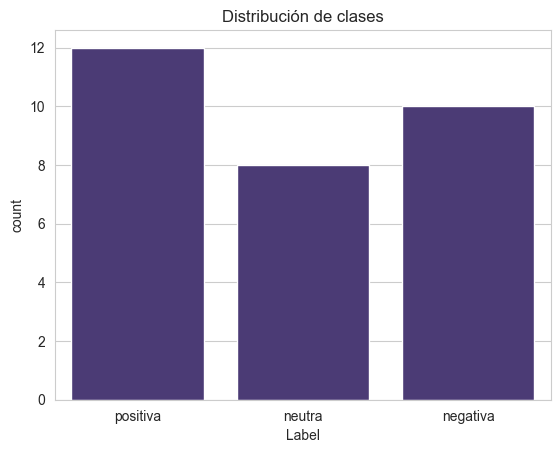

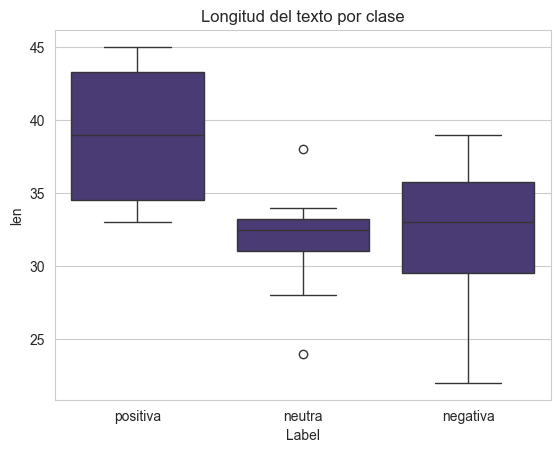

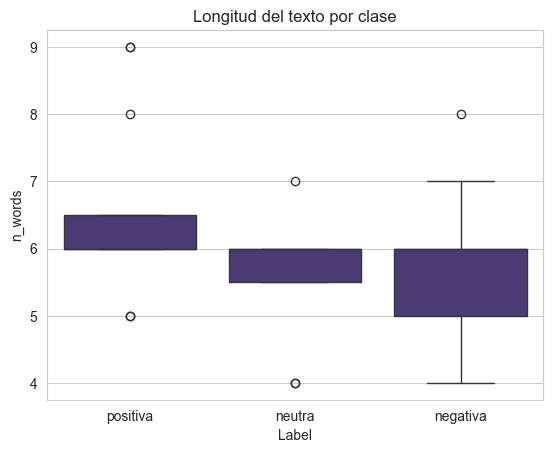

In [9]:


sns.countplot(data=opiniones, x="Label", order=["positiva","neutra","negativa"])
plt.title("Distribución de clases")
plt.show()

sns.boxplot(data=opiniones, x="Label", y="len", order=["positiva","neutra","negativa"])
plt.title("Longitud del texto por clase")
plt.show()

sns.boxplot(data=opiniones, x="Label", y="n_words", order=["positiva","neutra","negativa"])
plt.title("Longitud del texto por clase")
plt.show()

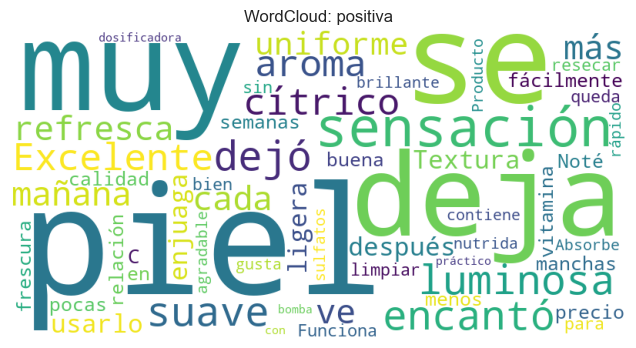

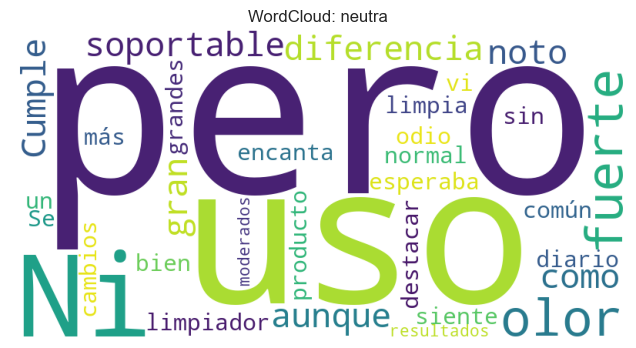

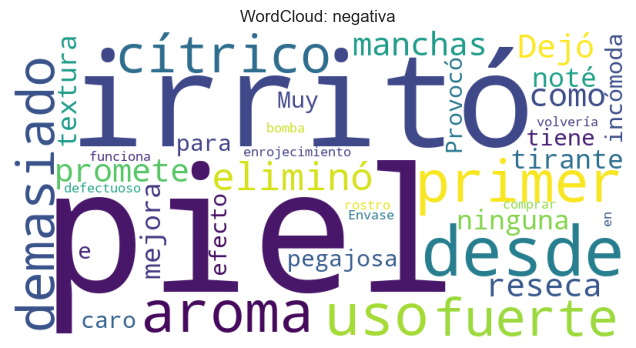

In [14]:
stop_es = set(STOPWORDS) | {"de","la","el","los","las","que","y","mi","me","lo","es"}

def nubes_por_clase(df, label):
    texto = " ".join(df.loc[df.Label==label, "Comentario"].astype(str))
    wc = WordCloud(width=800, height=400, stopwords=stop_es, background_color="white").generate(texto)
    plt.figure(figsize=(8,4)); plt.imshow(wc); plt.axis("off"); plt.title(f"WordCloud: {label}"); plt.show()

for lab in ["positiva","neutra","negativa"]:
    nubes_por_clase(opiniones, lab)

In [11]:
nlp = spacy.load("es_core_news_sm")

doc = nlp("Los estudiantes corriendo aprendieron rápidamente")
print([token.lemma_ for token in doc])

['el', 'estudiante', 'correr', 'aprender', 'rápidamente']


In [12]:
def lematizar(texto):
    doc = nlp(texto.lower())
    # quitamos puntuación, espacios y stopwords del modelo
    lemmas = [t.lemma_ for t in doc if not (t.is_punct or t.is_space or t.is_stop)]
    return " ".join(lemmas)

opiniones["Comentario_lem"] = opiniones["Comentario"].astype(str).apply(lematizar)
opiniones[["Comentario","Comentario_lem"]].head()

,Comentario,Comentario_lem
0,"Me encantó, dejó mi piel muy suave y luminosa",encantar piel suave luminoso
1,"Excelente aroma cítrico, refresca cada mañana",excelente aroma cítrico refrescar mañana
2,Mi piel se ve más uniforme después de usarlo,piel ver uniforme usar él
3,Textura ligera y se enjuaga fácilmente,textura ligero enjuagar fácilmente
4,Noté menos manchas en pocas semanas,noté mancha semana


In [17]:
cv = CountVectorizer(ngram_range=(1,2), min_df=1)
X_bow = cv.fit_transform(opiniones["Comentario_lem"])
y = opiniones["Label"]

cv.get_feature_names_out()[:20], X_bow.shape

(array(['absorbe', 'absorbe rápido', 'agradable', 'aroma', 'aroma cítrico',
        'bomba', 'bomba dosificadoro', 'bomba funcionar', 'brillante',
        'brillante nutrido', 'calidad', 'calidad precio', 'cambio',
        'cambio limpio', 'caro', 'caro efecto', 'comprar', 'común',
        'común destacar', 'contener'], dtype=object),
 (30, 142))

In [20]:
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1)
X_tfidf = tfidf.fit_transform(opiniones["Comentario_lem"])
X_tfidf.shape

(30, 142)

In [23]:
# Cambia X_bow por X_tfidf si quieres usar TF-IDF
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=200, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))
print(confusion_matrix(y_test, y_pred, labels=["positiva","neutra","negativa"]))

              precision    recall  f1-score   support

    negativa      0.000     0.000     0.000         3
      neutra      0.000     0.000     0.000         2
    positiva      0.444     1.000     0.615         4

    accuracy                          0.444         9
   macro avg      0.148     0.333     0.205         9
weighted avg      0.198     0.444     0.274         9

[[4 0 0]
 [2 0 0]
 [3 0 0]]


c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr